In [31]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import LeaveOneOutEncoder
from sklearn.ensemble import RandomForestRegressor
from scipy import stats ##
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_val_score

In [12]:
df2 = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\covid_19_clean_complete.csv',index_col=4,parse_dates=True) 
df2


,Province/State,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,,
2020-01-22,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,Eastern Mediterranean
2020-01-22,NaN,Albania,41.153300,20.168300,0,0,0,0,Europe
2020-01-22,NaN,Algeria,28.033900,1.659600,0,0,0,0,Africa
2020-01-22,NaN,Andorra,42.506300,1.521800,0,0,0,0,Europe
2020-01-22,NaN,Angola,-11.202700,17.873900,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
2020-07-27,NaN,Sao Tome and Principe,0.186400,6.613100,865,14,734,117,Africa
2020-07-27,NaN,Yemen,15.552727,48.516388,1691,483,833,375,Eastern Mediterranean
2020-07-27,NaN,Comoros,-11.645500,43.333300,354,7,328,19,Africa


In [9]:
df2.isna().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [13]:
df=df2[['Confirmed']]

In [14]:
df

,Confirmed
Date,
2020-01-22,0
2020-01-22,0
2020-01-22,0
2020-01-22,0
2020-01-22,0
...,...
2020-07-27,865
2020-07-27,1691
2020-07-27,354


<Axes: xlabel='Date'>

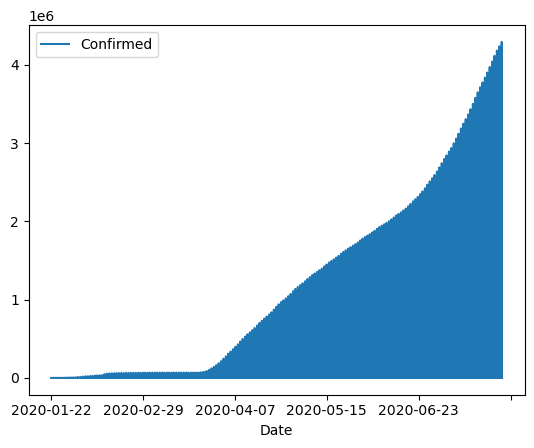

In [15]:
df.plot()

In [18]:
## Проверка на стационарность 
from statsmodels.tsa.stattools import kpss
# Проведение теста KPSS
stat, p_value, lags, crit_values = kpss(df, regression='c')

# Вывод результатов
print(f"KPSS Statistic: {stat}")
print(f"P-value: {p_value}")
print(f"Critical Values: {crit_values}")
print(f"Lags used: {lags}")


KPSS Statistic: 53.59385424134712
P-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Lags used: 46


C:\Users\User\AppData\Local\Temp\ipykernel_10336\3988120165.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit_values = kpss(df, regression='c')


<Axes: xlabel='Date'>

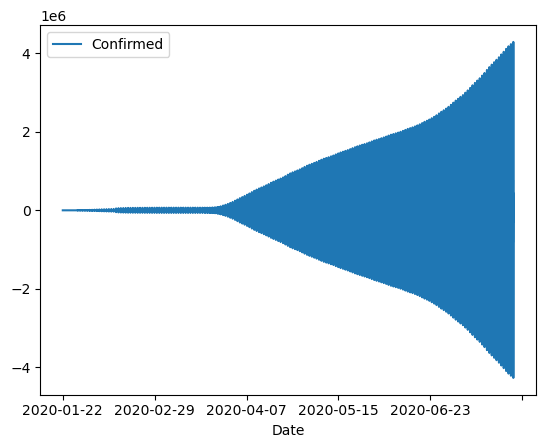

In [36]:
df3=df.diff()
df3.plot()

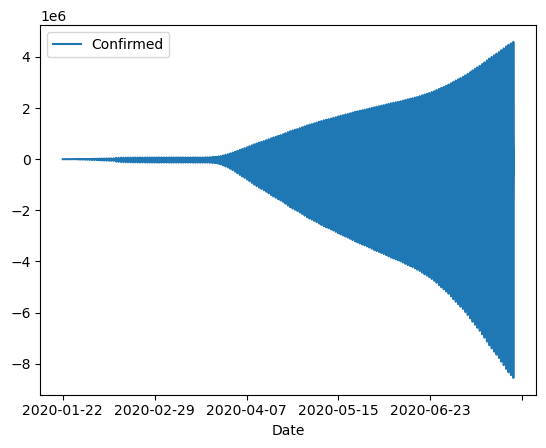

In [35]:
df4=df3.diff().plot()

In [40]:
log_data = np.log1p(df)

<Axes: xlabel='Date'>

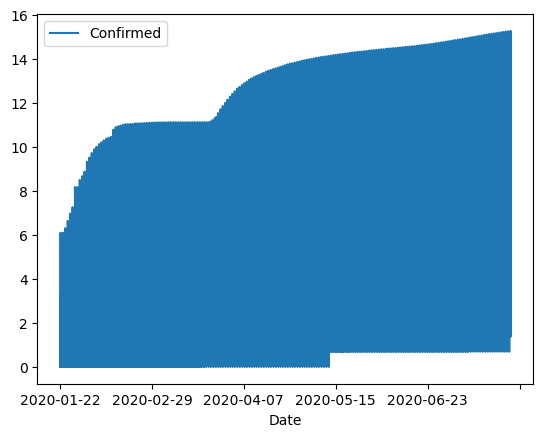

In [41]:
log_data.plot()

In [43]:
log_data1 = np.log1p(log_data)

In [45]:
log_data2 = np.log1p(log_data1)

<Axes: xlabel='Date'>

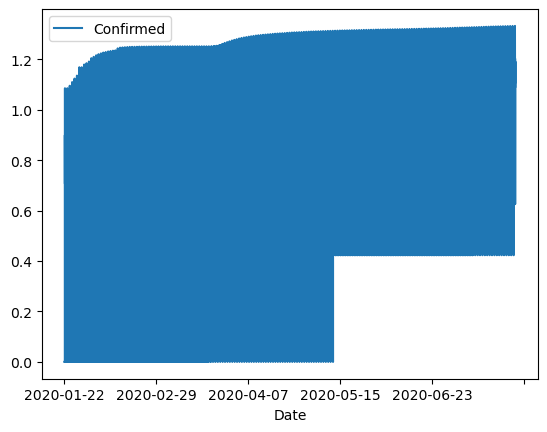

In [46]:
log_data2.plot()

In [42]:
## Проверка на стационарность 
from statsmodels.tsa.stattools import kpss
# Проведение теста KPSS
stat, p_value, lags, crit_values = kpss(log_data, regression='c')

# Вывод результатов
print(f"KPSS Statistic: {stat}")
print(f"P-value: {p_value}")
print(f"Critical Values: {crit_values}")
print(f"Lags used: {lags}")


KPSS Statistic: 33.92830125561511
P-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Lags used: 130


C:\Users\User\AppData\Local\Temp\ipykernel_10336\2636191511.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit_values = kpss(log_data, regression='c')


In [63]:
df_corr = df + abs(df.min()) + 1
bc_df = stats.boxcox(df_corr)

ValueError: Data must be 1-dimensional.